Data Source - https://www.kaggle.com/datasets/anmatngu/league-of-legends-worlds-2024-swiss-stage-stats

!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install scikit-learn  # use 'scikit-learn' for installation, but import as 'sklearn'
!pip install scipy
!pip install scikit-learn-extra  # This is an additional module for advanced sklearn features
!pip install plotly
!pip install xlsxwriter
!pip install openpyxl
!pip install pdfkit


In [1]:
import os
import glob
import datetime
import time

import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np  
import sklearn  
import scipy
import sklearn_extra  # sklearn_extra is an additional library related to sklearn
import plotly.express as px 
import xlsxwriter
import openpyxl
import pdfkit

from sklearn.preprocessing import StandardScaler


In [2]:
data = pd.read_csv('./champions.csv')

# preview the first few rows
print(data.head())
# check the structure and data types
print(data.info())

  Champion  Picks  Bans Presence  Wins  Losses Winrate  KDA Avg BT        GT  \
0   Aurora     14    60      96%   9.0     5.0     64%  5.6    3.5  33:36:00   
1     Yone     28    45      95%  18.0    10.0     64%  4.3    3.4  32:14:00   
2  Skarner     32    35      87%  23.0     9.0     72%  5.7    3.9  32:02:00   
3      Jax     35    28      82%  19.0    16.0     54%    3    5.2  34:25:00   
4     Ashe     18    43      79%  13.0     5.0     72%  6.2    6.1  33:30:00   

   CSM    DPM    GPM  CSD@15  GD@15  XPD@15  
0  7.6  684.0  394.0    -2.6   -7.0   -94.0  
1  9.5  645.0  442.0     5.4  303.0   265.0  
2  5.9  346.0  338.0    -0.8   11.0    82.0  
3  8.0  440.0  402.0    -5.1   38.0  -164.0  
4  9.5  553.0  444.0    -2.8 -156.0    17.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Champion  168 non-null    object 
 1   Picks     168 no

In [3]:
print(data.describe())
print(data.isnull().sum())

            Picks        Bans       Wins     Losses        CSM          DPM  \
count  168.000000  168.000000  86.000000  86.000000  86.000000    86.000000   
mean     4.583333    4.577381   4.476744   4.476744   6.719767   472.720930   
std      8.239976    9.792150   5.491655   4.737154   2.922884   214.606324   
min      0.000000    0.000000   0.000000   0.000000   0.700000    80.000000   
25%      0.000000    0.000000   1.000000   1.000000   5.800000   307.750000   
50%      1.000000    0.000000   2.000000   2.000000   7.600000   472.500000   
75%      4.000000    3.000000   6.750000   7.000000   8.700000   608.500000   
max     42.000000   60.000000  23.000000  22.000000  10.400000  1063.000000   

              GPM     CSD@15        GD@15       XPD@15  
count   86.000000  86.000000    86.000000    86.000000  
mean   364.604651   1.244186    53.813953    83.720930  
std     72.027491   9.442315   501.983232   457.776356  
min    217.000000 -28.000000  -995.000000 -1226.000000  
25%

## Pre-Processing

In [4]:
raw_data_path = 'champions.csv'
data = pd.read_csv(raw_data_path)

# helper functions for data cleaning
def safe_convert_percentage(column):
    if column.dtype == 'object':
        return column.str.rstrip('%').astype(float)
    return column

def safe_convert_time_to_minutes(time_str):
    try:
        h, m, s = map(int, time_str.split(':'))
        return h * 60 + m + s / 60
    except:
        return None

# Convert percentage columns to numeric
data['Presence'] = safe_convert_percentage(data['Presence'])
data['Winrate'] = safe_convert_percentage(data['Winrate'])

# Convert 'Kills-Deaths-Assists (KDA)' to numeric, handling non-numeric entries
data['KDA'] = pd.to_numeric(data['KDA'], errors='coerce')

# Convert 'Avg Build Time (BT)' to numeric, replacing invalid values
data['Avg BT'] = pd.to_numeric(data['Avg BT'], errors='coerce')

# Convert 'GT' (game time) from HH:MM:SS to total minutes
data['GT'] = data['GT'].apply(safe_convert_time_to_minutes)

# Handle missing values: Replace NaN with the median of each column for numeric fields
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Standardize the numeric columns for clustering 
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Champion  168 non-null    object 
 1   Picks     168 non-null    float64
 2   Bans      168 non-null    float64
 3   Presence  168 non-null    float64
 4   Wins      168 non-null    float64
 5   Losses    168 non-null    float64
 6   Winrate   168 non-null    float64
 7   KDA       168 non-null    float64
 8   Avg BT    168 non-null    float64
 9   GT        168 non-null    float64
 10  CSM       168 non-null    float64
 11  DPM       168 non-null    float64
 12  GPM       168 non-null    float64
 13  CSD@15    168 non-null    float64
 14  GD@15     168 non-null    float64
 15  XPD@15    168 non-null    float64
dtypes: float64(15), object(1)
memory usage: 21.1+ KB
None
  Champion     Picks      Bans  Presence      Wins    Losses   Winrate  \
0   Aurora  1.146219  5.676824  3.845131  1.398860  0.482519

## EDA

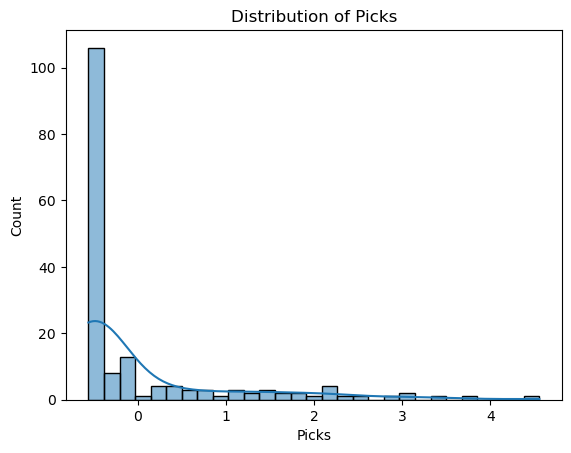

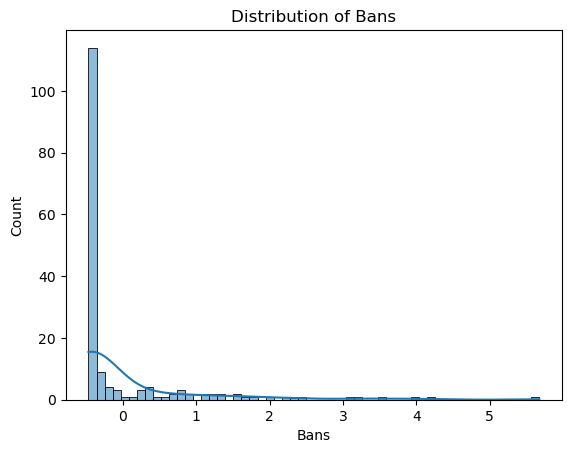

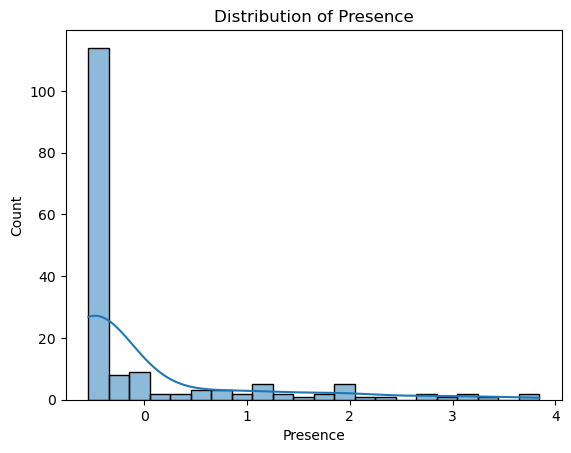

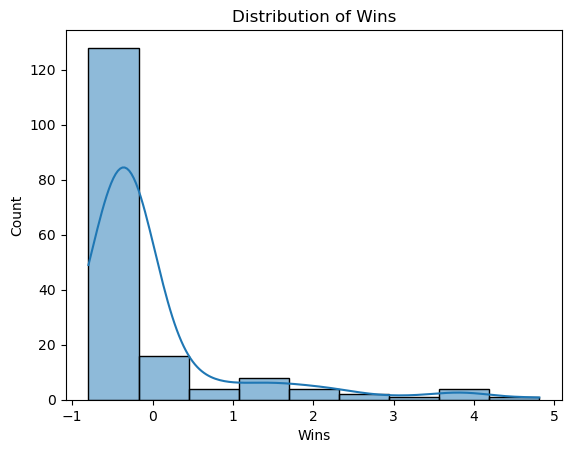

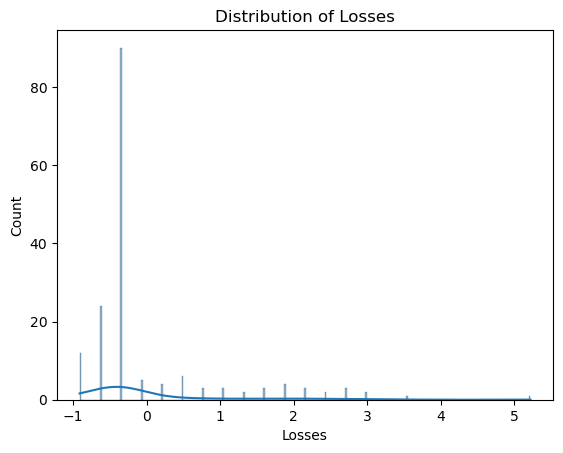

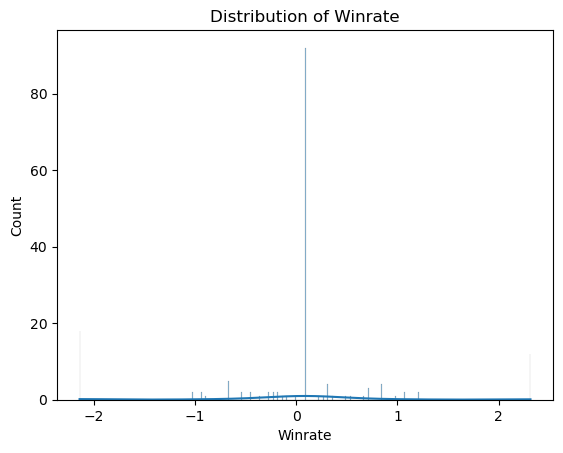

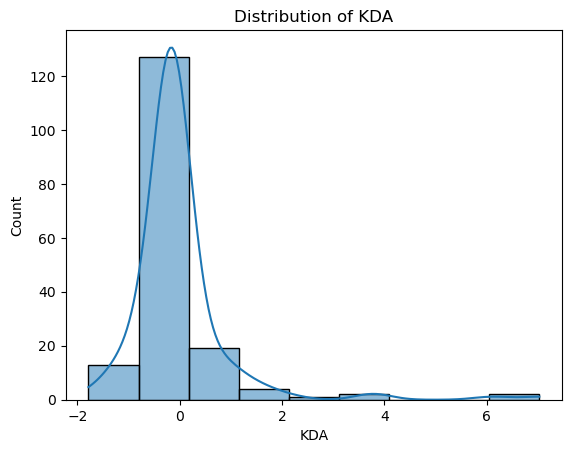

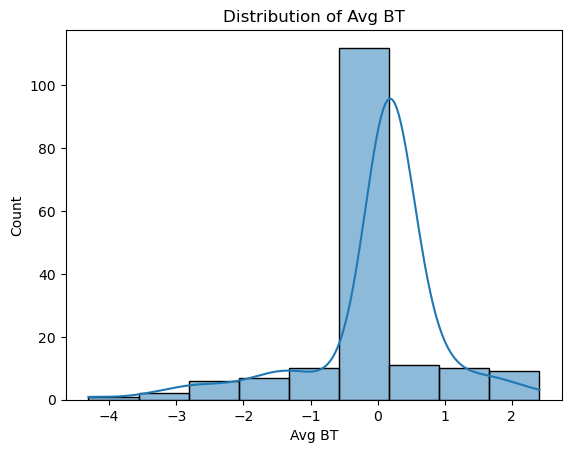

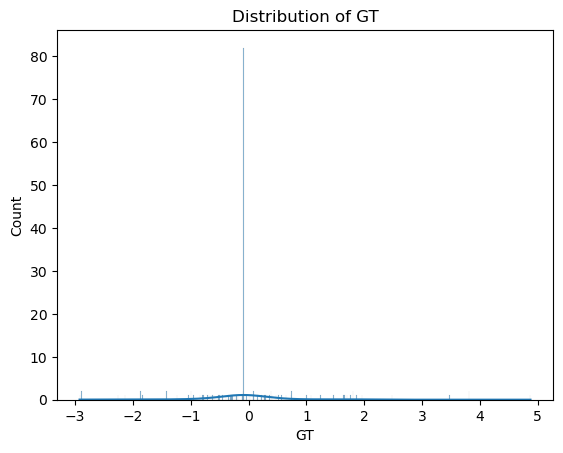

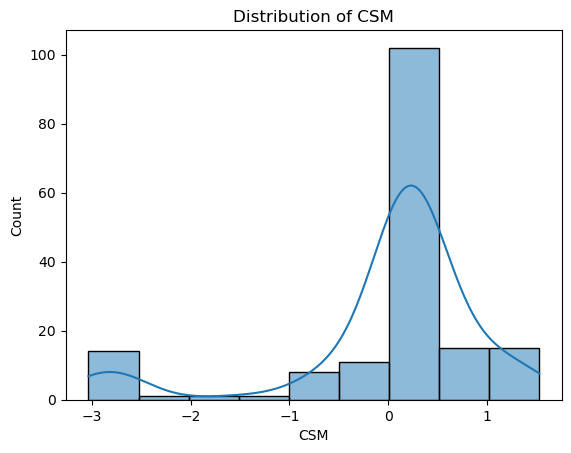

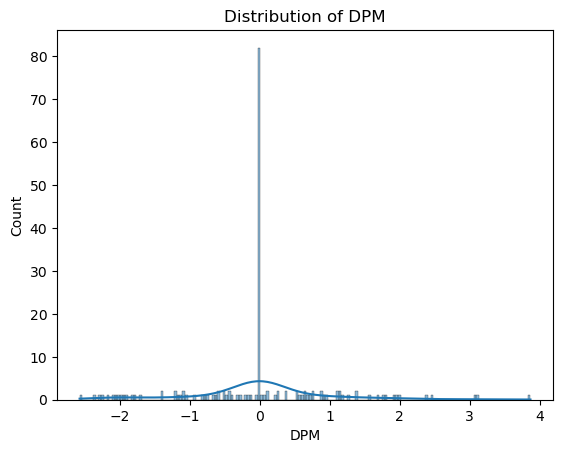

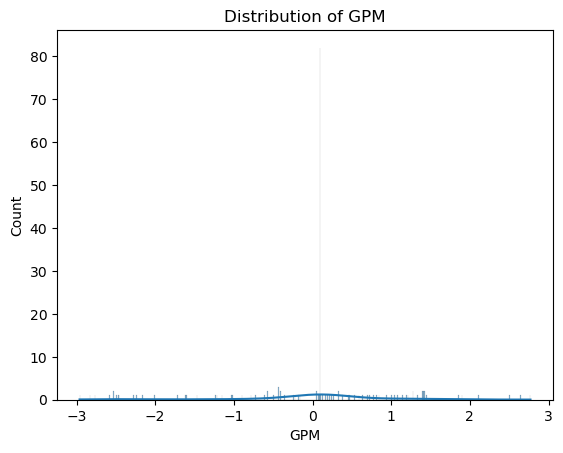

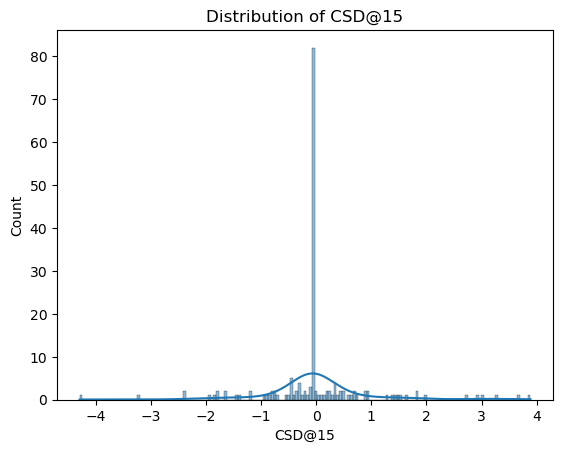

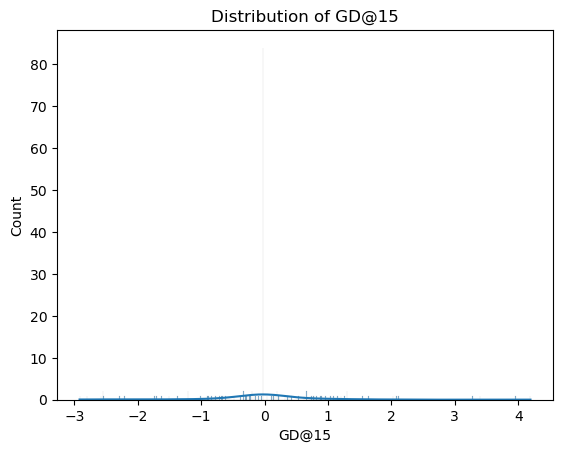

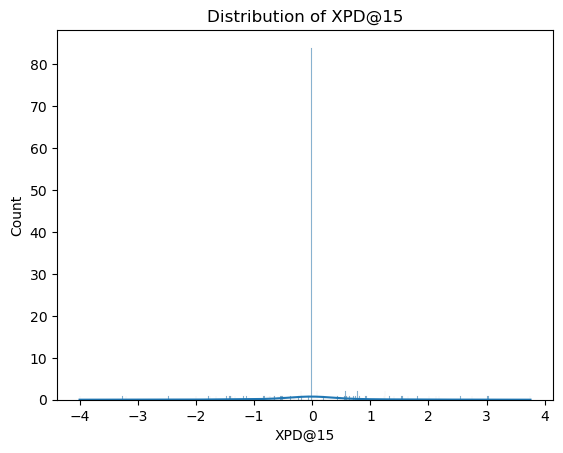

In [5]:
numerical_cols = ['Picks', 'Bans', 'Presence', 'Wins', 'Losses', 'Winrate', 'KDA', 'Avg BT', 'GT', 'CSM', 'DPM', 'GPM', 'CSD@15', 'GD@15', 'XPD@15']
for col in numerical_cols:
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

/Users/Arya/miniforge3/envs/venv-metal/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


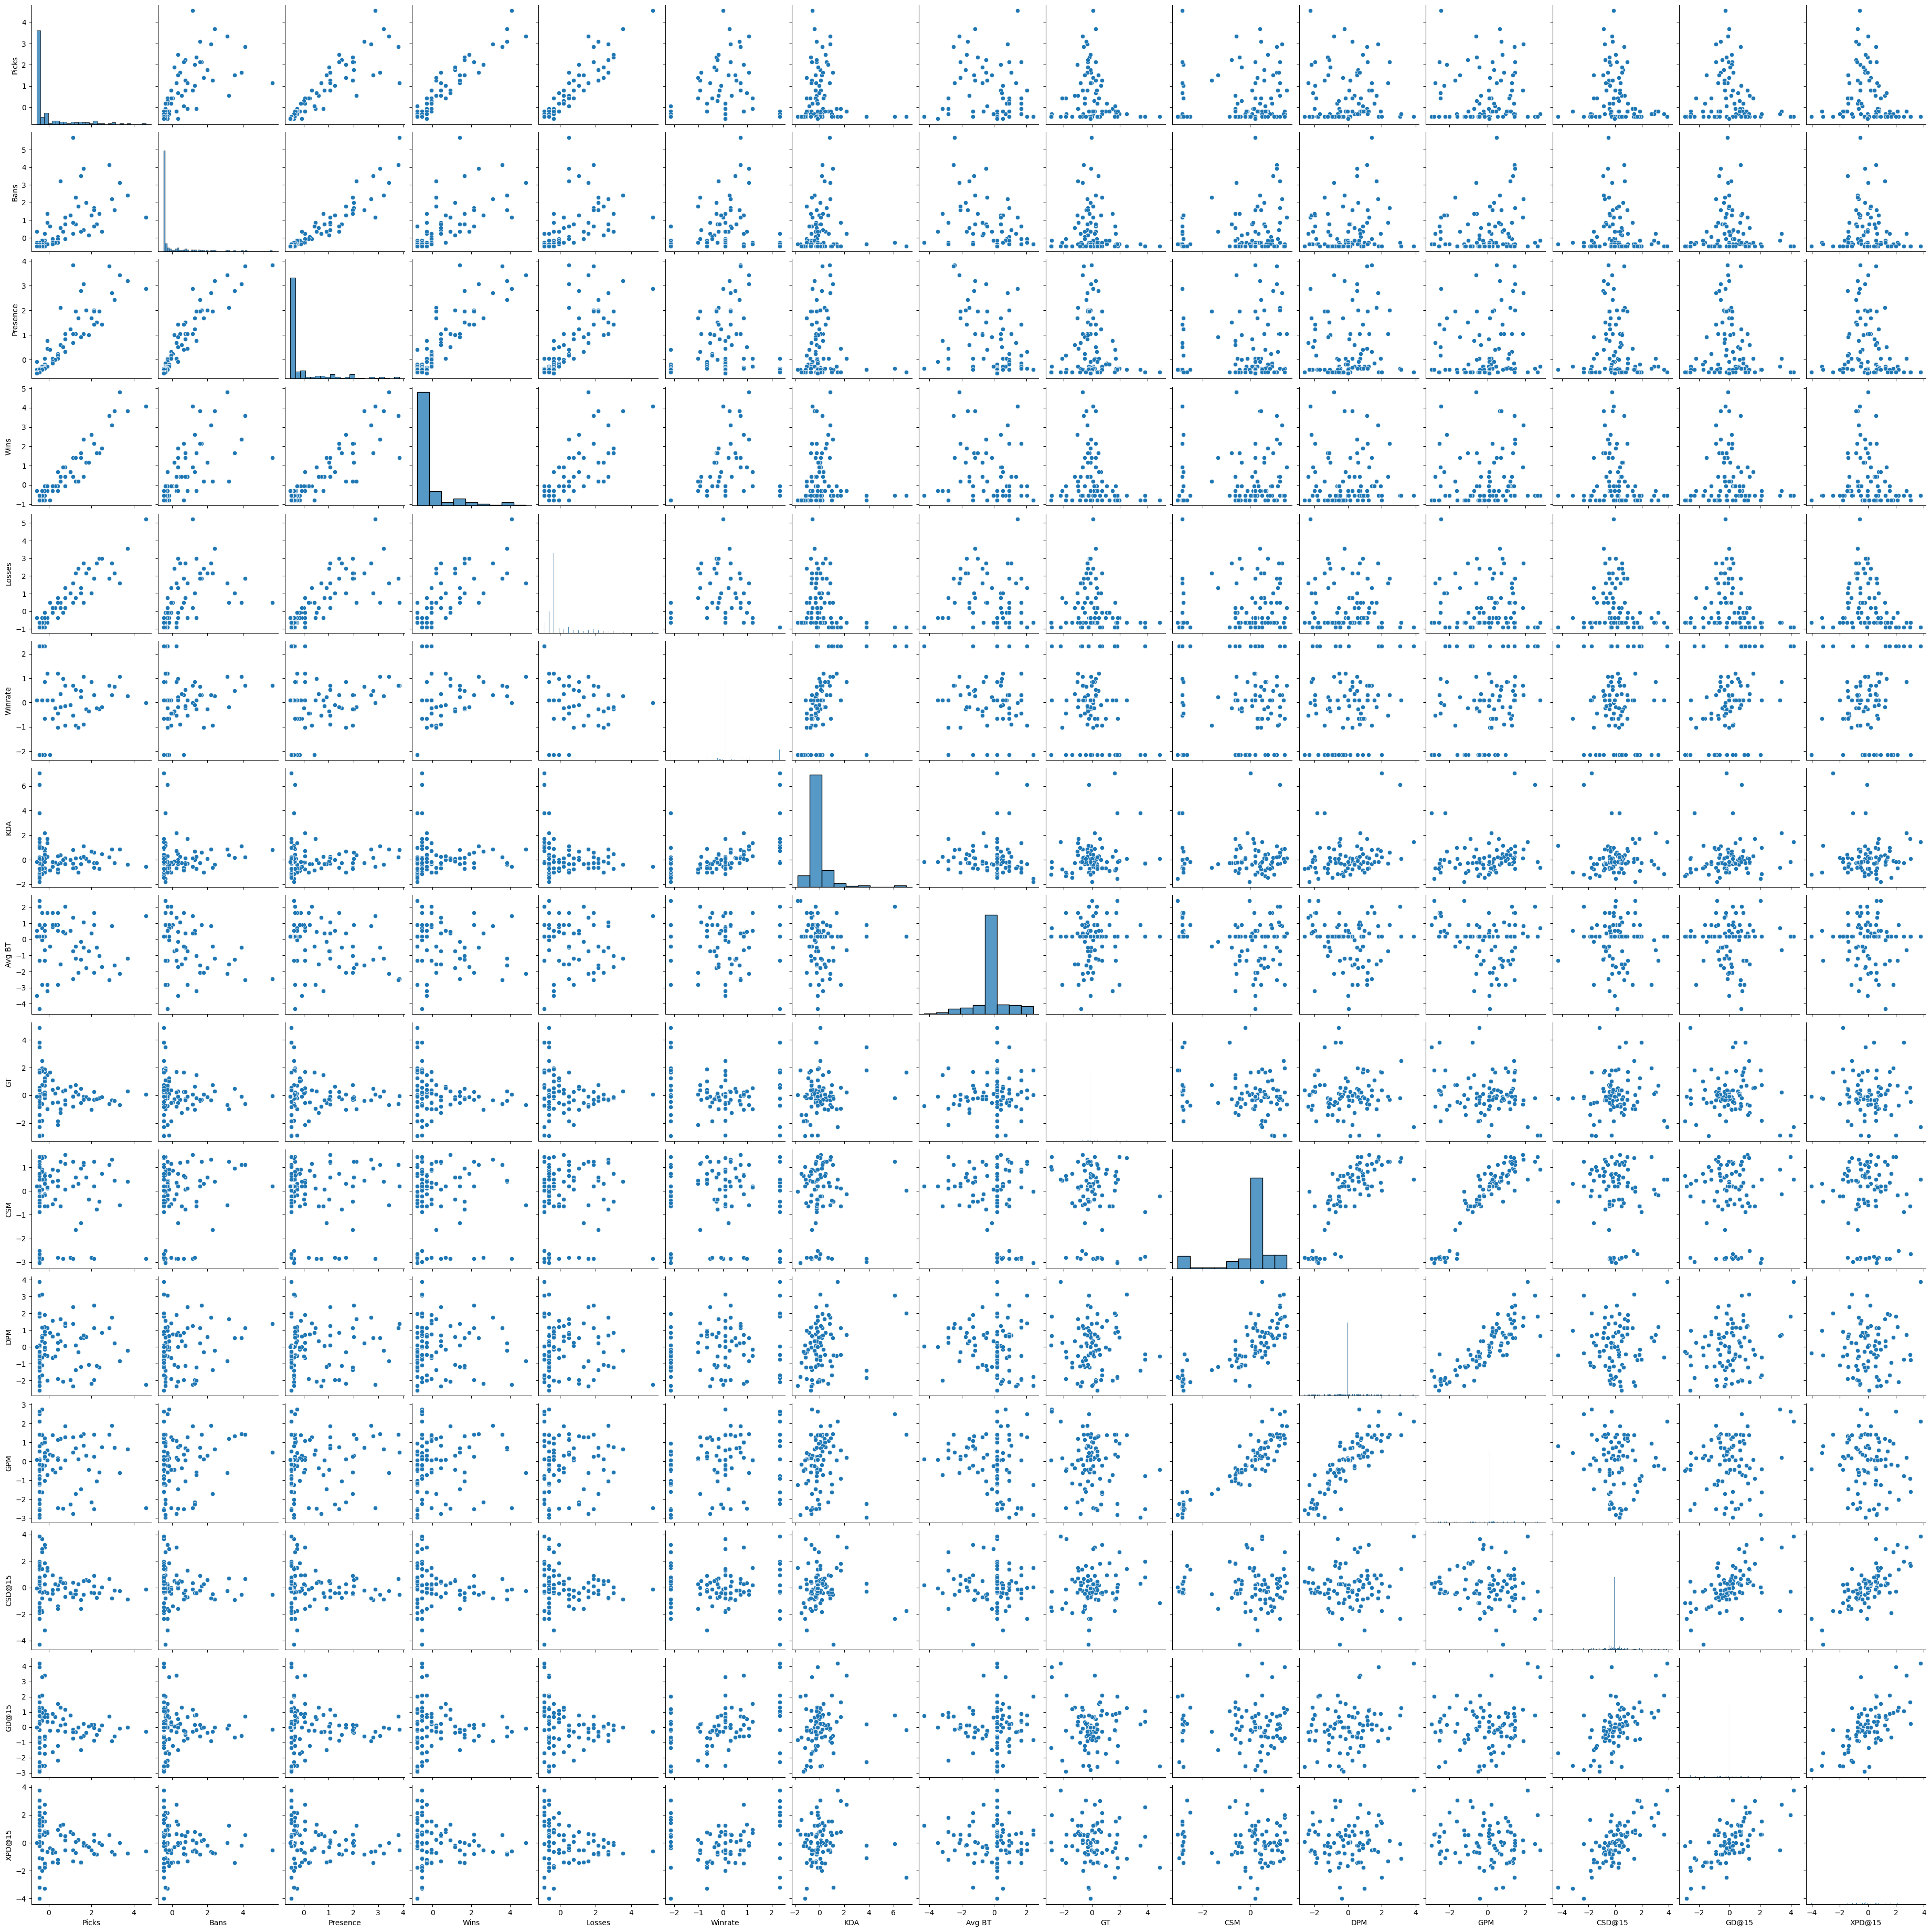

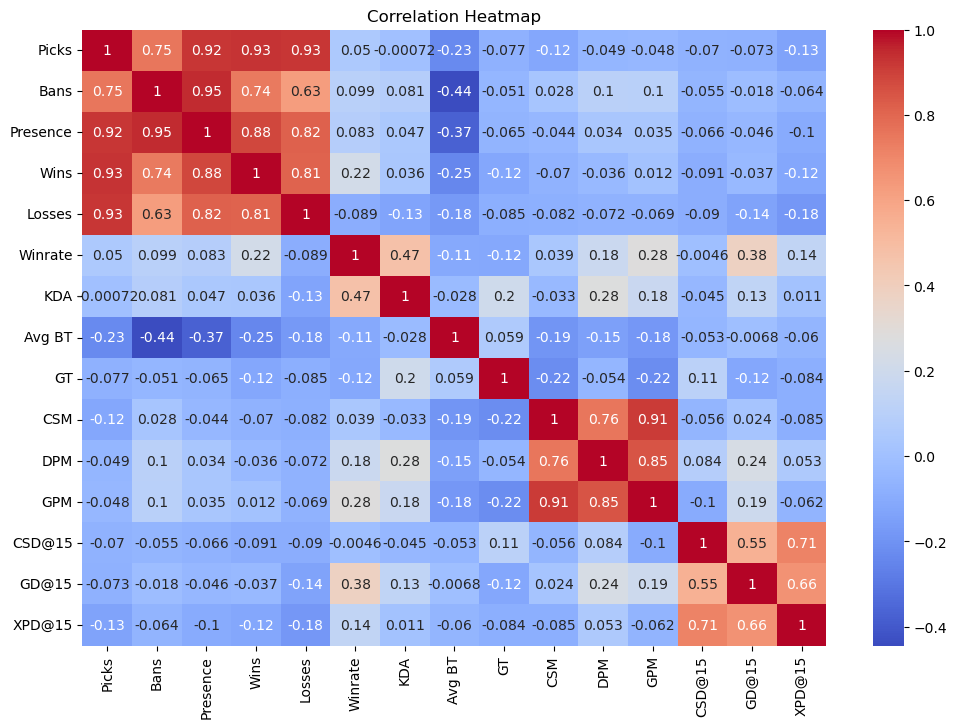

In [6]:
sns.pairplot(data[numerical_cols])
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [7]:
# Top 5 most popular champions based on Picks
most_picked_champs = data[['Champion', 'Picks']].sort_values(by='Picks', ascending=False).head(5)
print("Most Picked Champions:")
print(most_picked_champs)

# Top 5 champions with the most time played in games
most_time_played_champs = data[['Champion', 'GT']].sort_values(by='GT', ascending=False).head(5)
print("\nChampions with the Most Time Played:")
print(most_time_played_champs)

# Champion with the highest and lowest win rates
highest_winrate_champ = data[['Champion', 'Winrate']].sort_values(by='Winrate', ascending=False).head(5)
lowest_winrate_champ = data[['Champion', 'Winrate']].sort_values(by='Winrate', ascending=True).head(5)
print("\nChampion with Highest Winrate:")
print(highest_winrate_champ)
print("\nChampion with Lowest Winrate:")
print(lowest_winrate_champ)

# Champions with the highest and lowest CSD@15
highest_CSD15_champ = data[['Champion', 'CSD@15']].sort_values(by='CSD@15', ascending=False).head(5)
lowest_CSD15_champ = data[['Champion', 'CSD@15']].sort_values(by='CSD@15', ascending=True).head(5)
print("\nChampion with Highest Creep Score Difference (CSD) @ 15 Minutes:")
print(highest_CSD15_champ)
print("\nChampion with Lowest Creep Score Difference (CSD) @ 15 Minutes:")
print(lowest_CSD15_champ)

# Champions with the highest and lowest GD@15
highest_GD15_champ = data[['Champion', 'GD@15']].sort_values(by='GD@15', ascending=False).head(5)
lowest_GD15_champ = data[['Champion', 'GD@15']].sort_values(by='GD@15', ascending=True).head(5)
print("\nChampion with Highest Gold Difference (GD) @ 15 Minutes:")
print(highest_GD15_champ)
print("\nChampion with Lowest Gold Difference (GD) @ 15 Minutes:")
print(lowest_GD15_champ)

# Champions with the highest and lowest XPD@15
highest_XPD15_champ = data[['Champion', 'XPD@15']].sort_values(by='XPD@15', ascending=False).head(5)
lowest_XPD15_champ = data[['Champion', 'XPD@15']].sort_values(by='XPD@15', ascending=True).head(5)
print("\nChampion with Highest Experience Difference (XPD) @ 15 Minutes:")
print(highest_XPD15_champ)
print("\nChampion with Lowest Experience Difference (XPD) @ 15 Minutes")
print(lowest_XPD15_champ)


Most Picked Champions:
  Champion     Picks
5     Rell  4.554446
3      Jax  3.702389
2  Skarner  3.337222
8     Gnar  3.093777
7    Kaisa  2.972055

Champions with the Most Time Played:
   Champion        GT
87   Lillia  4.876504
78      Lux  3.817310
77  Lee Sin  3.817310
64     Nami  3.477825
71     Zeri  2.479738

Champion with Highest Winrate:
     Champion   Winrate
60  Seraphine  2.315547
69       Pyke  2.315547
62  Jarvan Iv  2.315547
79    Morgana  2.315547
40    Leblanc  2.315547

Champion with Lowest Winrate:
      Champion   Winrate
51        Zyra -2.140999
68  Tahm Kench -2.140999
70       Viego -2.140999
72      Darius -2.140999
55        Jinx -2.140999

Champion with Highest Creep Score Difference (CSD) @ 15 Minutes:
   Champion    CSD@15
75    Jayce  3.885727
66     Sion  3.662781
51     Zyra  3.246614
38    Brand  3.038531
52  Kindred  2.919626

Champion with Lowest Creep Score Difference (CSD) @ 15 Minutes:
     Champion    CSD@15
62  Jarvan Iv -4.288977
50       Olaf

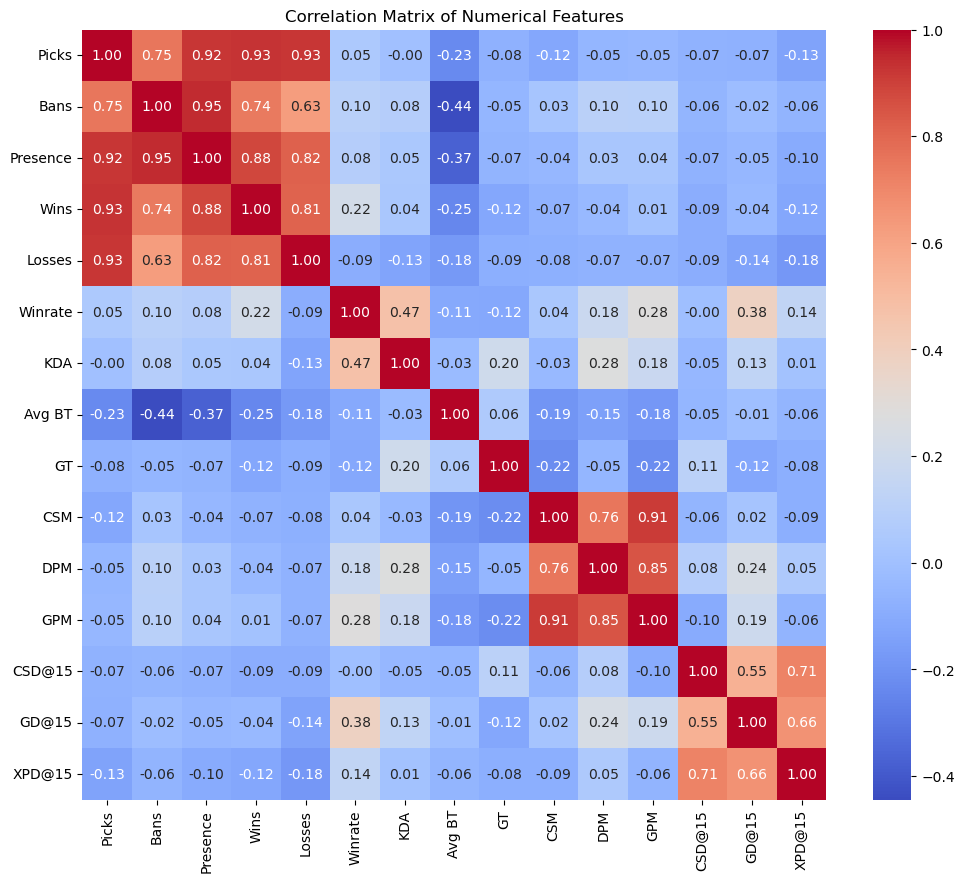

In [8]:
# correlation matrix - identify relationships
correlation_matrix = data[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [9]:
# Feature selection for clustering
selected_features = ['Picks', 'Bans', 'Presence', 'Winrate', 'KDA', 'GT', 'DPM', 'GPM']
data_selected = data[selected_features]

print(data_selected.info())
print(data_selected.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Picks     168 non-null    float64
 1   Bans      168 non-null    float64
 2   Presence  168 non-null    float64
 3   Winrate   168 non-null    float64
 4   KDA       168 non-null    float64
 5   GT        168 non-null    float64
 6   DPM       168 non-null    float64
 7   GPM       168 non-null    float64
dtypes: float64(8)
memory usage: 10.6 KB
None
      Picks      Bans  Presence   Winrate       KDA        GT       DPM  \
0  1.146219  5.676824  3.845131  0.711191  0.813596 -0.039243  1.384780   
1  2.850333  4.140405  3.799421  0.711191  0.210441 -0.595999  1.129293   
2  3.337222  3.116126  3.433736  1.067714  0.859993 -0.677475 -0.829433   
3  3.702389  2.399130  3.205183  0.265536 -0.392713  0.293453 -0.213646   
4  1.633109  3.935549  3.068051  1.067714  1.091975 -0.079981  0.526608   

        G

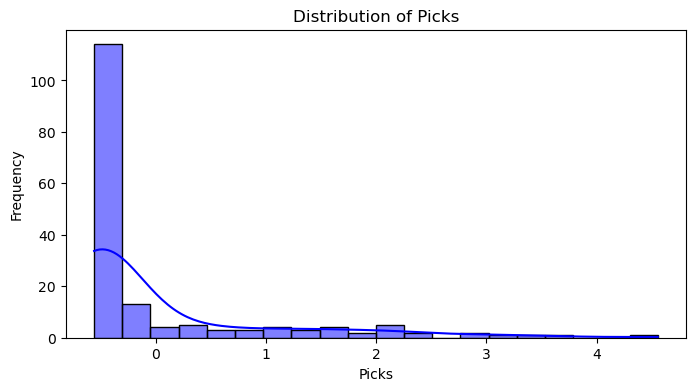

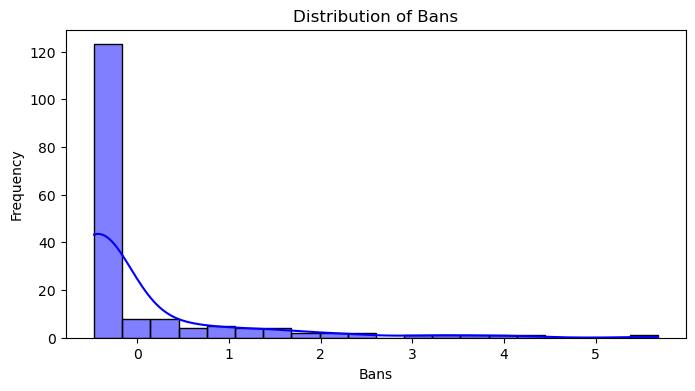

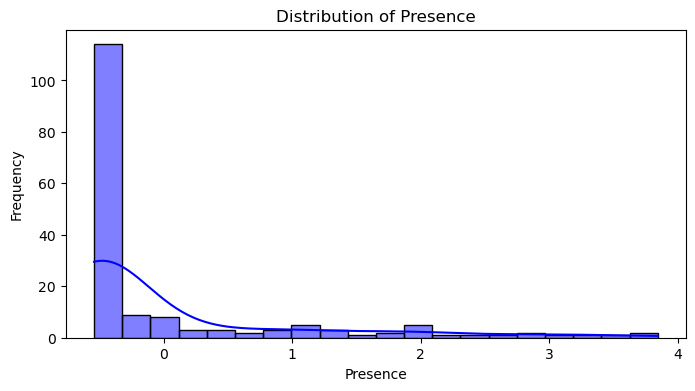

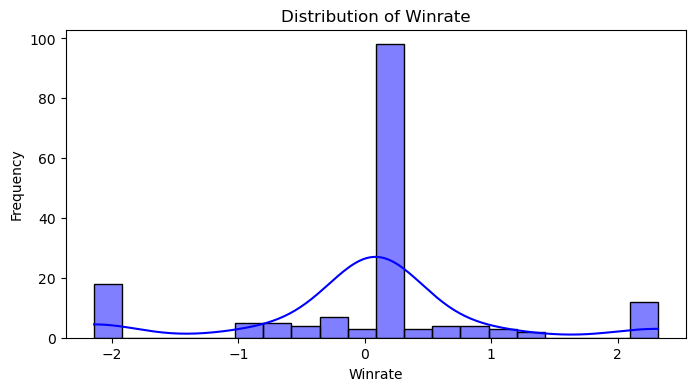

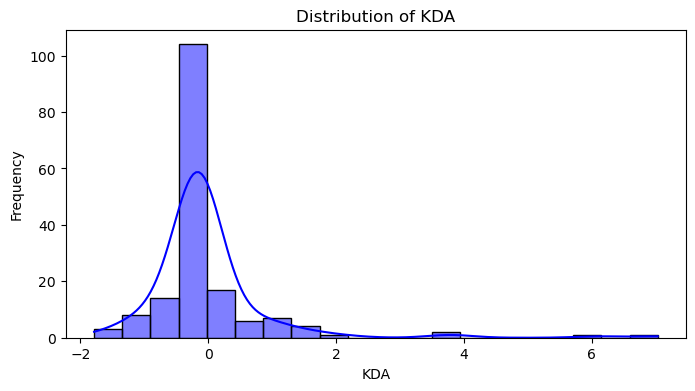

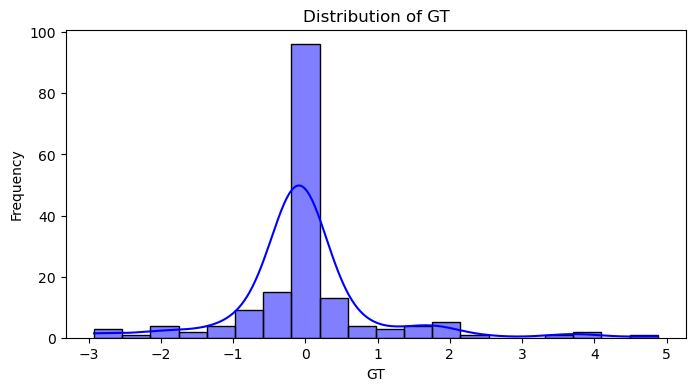

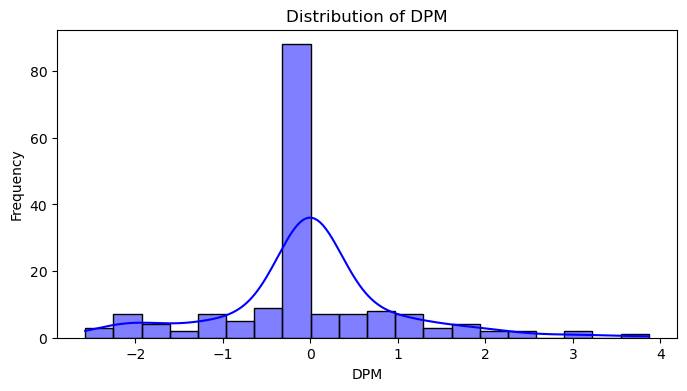

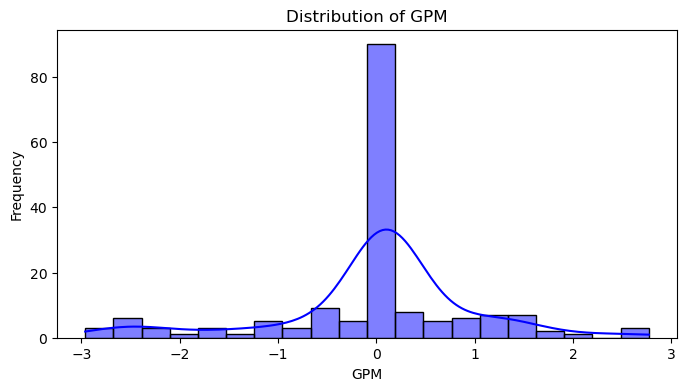

In [10]:
# Exploratory Data Analysis (EDA)
# Plot distributions of selected features
for col in selected_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data_selected[col], kde=True, bins=20, color='blue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

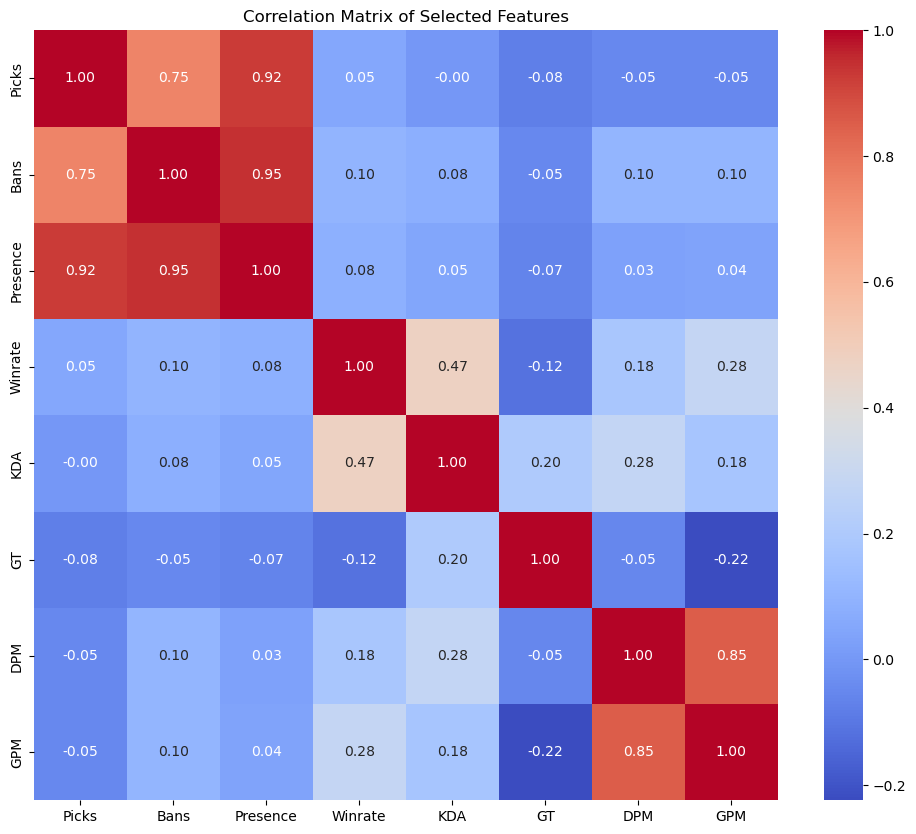

In [11]:
# correlation matrix of selected features
correlation_matrix = data_selected.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Selected Features")
plt.show()


## Clustering

In [12]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Extract relevant features for clustering (exclude 'Champion' as it's not numeric)
features = data_selected #.drop(columns=['Champion'])

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) 
kmeans_labels = kmeans.fit_predict(features)
kmeans_silhouette = silhouette_score(features, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(features, kmeans_labels)

# DBSCAN Clustering
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(features)
dbscan_silhouette = silhouette_score(features, dbscan_labels) if len(set(dbscan_labels)) > 1 else None
dbscan_davies_bouldin = davies_bouldin_score(features, dbscan_labels) if len(set(dbscan_labels)) > 1 else None

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3) 
hierarchical_labels = hierarchical.fit_predict(features)
hierarchical_silhouette = silhouette_score(features, hierarchical_labels)
hierarchical_davies_bouldin = davies_bouldin_score(features, hierarchical_labels)


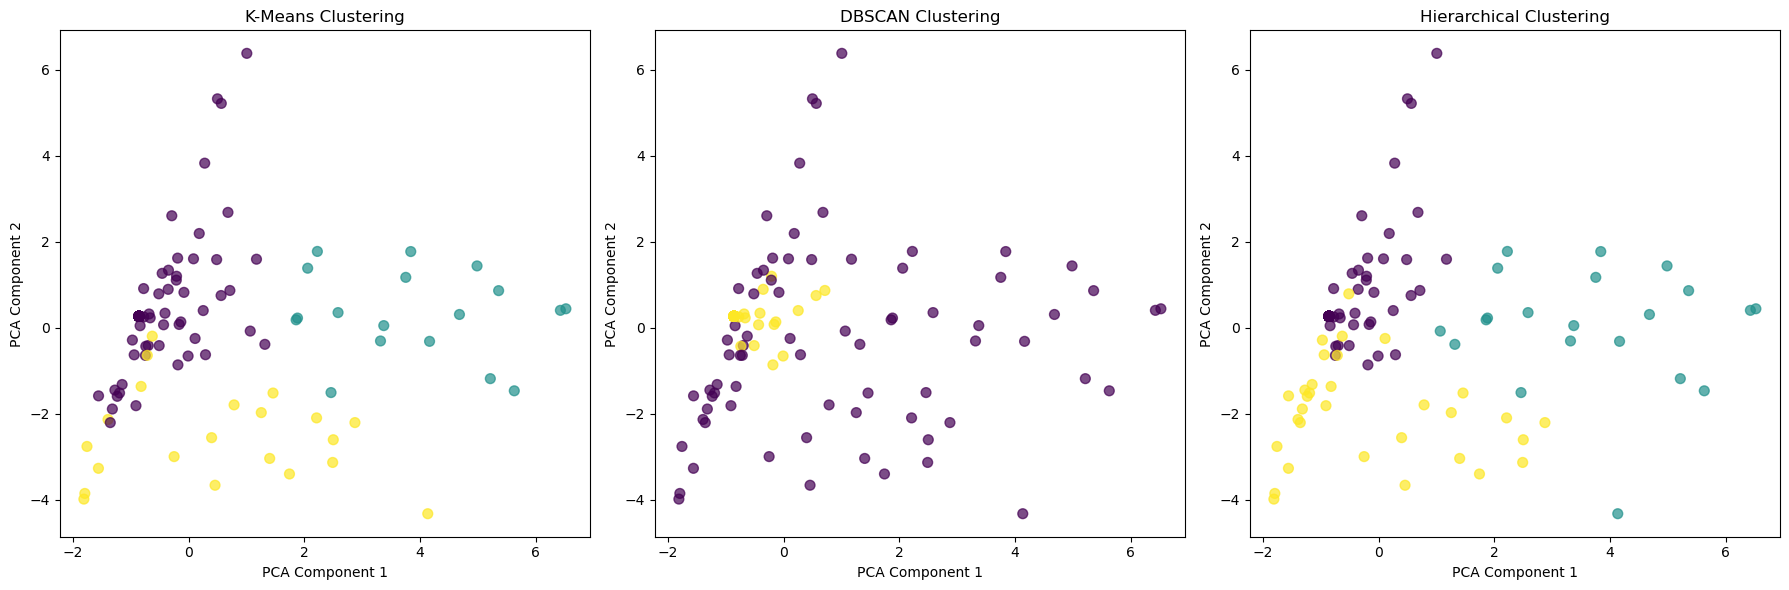

In [13]:
# Dimensionality Reduction for Visualization (PCA)
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# Visualize Clusters for Each Method
plt.figure(figsize=(18, 6))

# K-Means Visualization
plt.subplot(1, 3, 1)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.7)
plt.title("K-Means Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# DBSCAN Visualization
plt.subplot(1, 3, 2)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=dbscan_labels, cmap='viridis', s=50, alpha=0.7)
plt.title("DBSCAN Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Hierarchical Clustering Visualization
plt.subplot(1, 3, 3)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=hierarchical_labels, cmap='viridis', s=50, alpha=0.7)
plt.title("Hierarchical Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

In [14]:
results_summary = {
    "K-Means": {
        "Silhouette Score": kmeans_silhouette,
        "Davies-Bouldin Index": kmeans_davies_bouldin,
        "Clusters": len(set(kmeans_labels))
    },
    "DBSCAN": {
        "Silhouette Score": dbscan_silhouette,
        "Davies-Bouldin Index": dbscan_davies_bouldin,
        "Clusters": len(set(dbscan_labels))
    },
    "Hierarchical": {
        "Silhouette Score": hierarchical_silhouette,
        "Davies-Bouldin Index": hierarchical_davies_bouldin,
        "Clusters": len(set(hierarchical_labels))
    }
}

results_summary

{'K-Means': {'Silhouette Score': 0.5107616946236283,
  'Davies-Bouldin Index': 1.1705278895228528,
  'Clusters': 3},
 'DBSCAN': {'Silhouette Score': 0.40738263025403654,
  'Davies-Bouldin Index': 2.131917778633947,
  'Clusters': 2},
 'Hierarchical': {'Silhouette Score': 0.48186206757796735,
  'Davies-Bouldin Index': 1.4844473248179577,
  'Clusters': 3}}

### Optimizing Clustering Performance

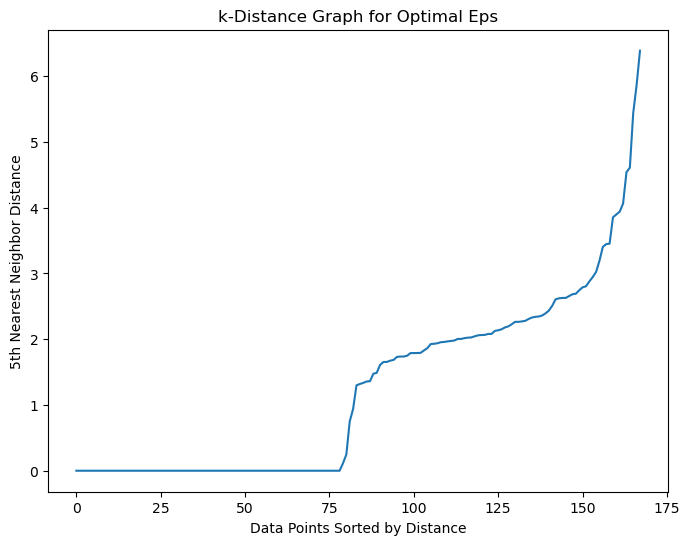

{'DBSCAN': {'Eps': 1.0,
  'Silhouette Score': 0.3583554638629647,
  'Davies-Bouldin Index': 1.9392683697433402,
  'Clusters': 2},
 'K-Means': {'Optimal k': 8,
  'Silhouette Score': 0.5573112636287669,
  'Davies-Bouldin Index': 0.9578652135294986,
  'Clusters': 8},
 'Hierarchical': {'Optimal Clusters': 8,
  'Silhouette Score': 0.5326056267898468,
  'Davies-Bouldin Index': 1.0617005030393585,
  'Clusters': 8}}

In [15]:
from sklearn.neighbors import NearestNeighbors

# Determine optimal eps for DBSCAN using k-distance graph
nearest_neighbors = NearestNeighbors(n_neighbors=5)  # Using 5 as min_samples parameter
neighbors = nearest_neighbors.fit(features)
distances, indices = neighbors.kneighbors(features)

# Sort distances to observe elbow point
sorted_distances = np.sort(distances[:, -1])

# Plot k-distance graph
plt.figure(figsize=(8, 6))
plt.plot(sorted_distances)
plt.title("k-Distance Graph for Optimal Eps")
plt.xlabel("Data Points Sorted by Distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.show()

# Based on the graph, select a reasonable eps value and reapply DBSCAN
optimized_eps = 1.0  # Replace this value based on the elbow point in the graph

dbscan_optimized = DBSCAN(eps=optimized_eps, min_samples=5)
dbscan_labels_optimized = dbscan_optimized.fit_predict(features)

# Evaluate the optimized DBSCAN
if len(set(dbscan_labels_optimized)) > 1:
    dbscan_optimized_silhouette = silhouette_score(features, dbscan_labels_optimized)
    dbscan_optimized_davies_bouldin = davies_bouldin_score(features, dbscan_labels_optimized)
else:
    dbscan_optimized_silhouette = None
    dbscan_optimized_davies_bouldin = None

# Re-run K-Means with multiple values of k to determine the best number of clusters
k_values = range(2, 10)
kmeans_silhouette_scores = []
kmeans_davies_bouldin_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features)
    kmeans_silhouette_scores.append(silhouette_score(features, labels))
    kmeans_davies_bouldin_scores.append(davies_bouldin_score(features, labels))

# Find the best k based on silhouette score and Davies-Bouldin Index
optimal_k = k_values[np.argmax(kmeans_silhouette_scores)]

# Re-run K-Means with the optimal number of clusters
kmeans_optimized = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels_optimized = kmeans_optimized.fit_predict(features)

# Hierarchical Clustering: Re-run with optimal parameters (e.g., n_clusters from K-Means optimal_k)
hierarchical_optimized = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels_optimized = hierarchical_optimized.fit_predict(features)

# Evaluate Hierarchical Clustering
hierarchical_optimized_silhouette = silhouette_score(features, hierarchical_labels_optimized)
hierarchical_optimized_davies_bouldin = davies_bouldin_score(features, hierarchical_labels_optimized)

# Summarize optimized results
optimized_results = {
    "DBSCAN": {
        "Eps": optimized_eps,
        "Silhouette Score": dbscan_optimized_silhouette,
        "Davies-Bouldin Index": dbscan_optimized_davies_bouldin,
        "Clusters": len(set(dbscan_labels_optimized))
    },
    "K-Means": {
        "Optimal k": optimal_k,
        "Silhouette Score": max(kmeans_silhouette_scores),
        "Davies-Bouldin Index": kmeans_davies_bouldin_scores[np.argmax(kmeans_silhouette_scores)],
        "Clusters": optimal_k
    },
    "Hierarchical": {
        "Optimal Clusters": optimal_k,
        "Silhouette Score": hierarchical_optimized_silhouette,
        "Davies-Bouldin Index": hierarchical_optimized_davies_bouldin,
        "Clusters": optimal_k
    }
}

optimized_results


In [16]:
# Add cluster labels to the dataset for both K-Means and Hierarchical Clustering
data_selected['K-Means Cluster'] = kmeans_labels_optimized
data_selected['Hierarchical Cluster'] = hierarchical_labels_optimized

# Recalculate cluster summaries excluding non-numeric columns (e.g., 'Champion')
kmeans_cluster_summary = data_selected.groupby('K-Means Cluster').mean(numeric_only=True)
hierarchical_cluster_summary = data_selected.groupby('Hierarchical Cluster').mean(numeric_only=True)

# Display the updated summaries for review
print(kmeans_cluster_summary)
print(hierarchical_cluster_summary)



                    Picks      Bans  Presence   Winrate       KDA        GT  \
K-Means Cluster                                                               
0                1.971226  2.245488  2.263037  0.225922  0.210441 -0.215775   
1               -0.443263 -0.386313 -0.439238  0.126215 -0.107127 -0.143659   
2                1.476608  0.774916  1.171062  0.135023 -0.303234 -0.158063   
3               -0.436172 -0.366424 -0.428809  2.315547  6.566766  0.717809   
4               -0.415885 -0.426173 -0.455473 -2.140999 -0.868278 -0.146747   
5               -0.126333 -0.217438 -0.189867 -0.885063 -0.173384  1.714970   
6               -0.395598 -0.366424 -0.421190  1.572790  0.225907 -2.682702   
7               -0.411827 -0.427880 -0.442522  1.424238  2.001347  2.080503   

                      DPM       GPM  Hierarchical Cluster  
K-Means Cluster                                            
0                0.855610  0.892810              1.000000  
1                0.016018  0.

/var/folders/8v/6fds7wl53y707fgtm7_zvjm80000gp/T/ipykernel_41106/684987248.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_selected['K-Means Cluster'] = kmeans_labels_optimized
/var/folders/8v/6fds7wl53y707fgtm7_zvjm80000gp/T/ipykernel_41106/684987248.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_selected['Hierarchical Cluster'] = hierarchical_labels_optimized


In [17]:
# Add clustering labels to data_selected
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(data_selected)
data_selected['KMeans_Cluster'] = kmeans_labels

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(data_selected)
data_selected['DBSCAN_Cluster'] = dbscan_labels

hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(data_selected)
data_selected['Hierarchical_Cluster'] = hierarchical_labels

/Users/Arya/miniforge3/envs/venv-metal/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/var/folders/8v/6fds7wl53y707fgtm7_zvjm80000gp/T/ipykernel_41106/136671847.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_selected['KMeans_Cluster'] = kmeans_labels
/var/folders/8v/6fds7wl53y707fgtm7_zvjm80000gp/T/ipykernel_41106/136671847.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

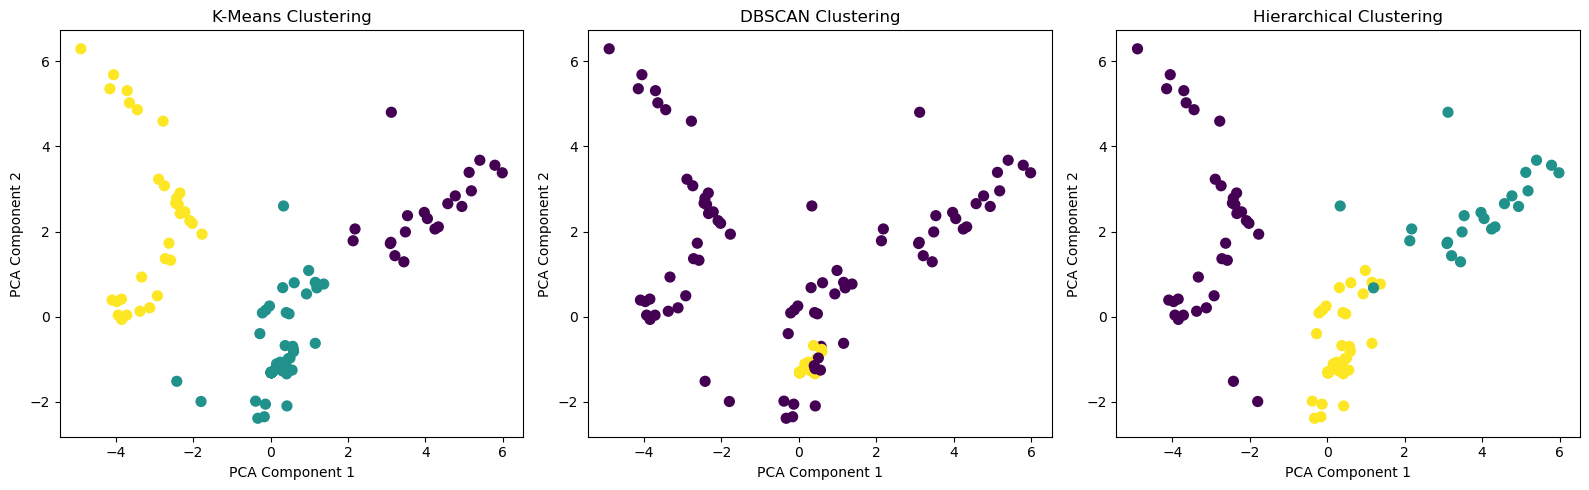

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA for Visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(data_selected)

# Visualize Clusters
plt.figure(figsize=(16, 5))

# K-Means Clusters
plt.subplot(1, 3, 1)
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=data_selected['KMeans_Cluster'], cmap='viridis', s=50)
plt.title('K-Means Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# DBSCAN Clusters
plt.subplot(1, 3, 2)
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=data_selected['DBSCAN_Cluster'], cmap='viridis', s=50)
plt.title('DBSCAN Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Hierarchical Clusters
plt.subplot(1, 3, 3)
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=data_selected['Hierarchical_Cluster'], cmap='viridis', s=50)
plt.title('Hierarchical Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

In [19]:
# Interpretation
# Summarize cluster characteristics
print("K-Means Cluster Summary:")
print(data_selected.groupby('KMeans_Cluster').mean())

print("DBSCAN Cluster Summary:")
print(data_selected.groupby('DBSCAN_Cluster').mean())

print("Hierarchical Cluster Summary:")
print(data_selected.groupby('Hierarchical_Cluster').mean())


K-Means Cluster Summary:
                   Picks      Bans  Presence   Winrate       KDA        GT  \
KMeans_Cluster                                                               
0               1.969294  2.043071  2.145133  0.203993  0.124276 -0.256837   
1              -0.273526 -0.277241 -0.293253  0.166416 -0.008342 -0.121246   
2              -0.310523 -0.346599 -0.355819 -0.760907 -0.052971  0.627681   

                     DPM       GPM  K-Means Cluster  Hierarchical Cluster  \
KMeans_Cluster                                                              
0               0.647021  0.634538         0.190476              1.000000   
1              -0.138819 -0.044451         1.146552              4.189655   
2               0.081146 -0.263515         5.032258              2.935484   

                DBSCAN_Cluster  Hierarchical_Cluster  
KMeans_Cluster                                        
0                    -1.000000              1.000000  
1                    -0.232759   